# Task 2 - Music Segment GraphSAGE and Mel-CNN

This notebook implements the proposal's audio-only Task 2:

1. load permitted local audio and multi-label targets,
2. extract log-mel/chroma/MFCC segment features,
3. build temporal, temporal+similarity, and random-control graphs,
4. compare pooled MLP, compact mel-CNN, and GraphSAGE, and
5. save measured metrics, checkpoints, curves, and predictions.

> **Result policy:** the default synthetic mode is only a pipeline smoke test. Its scores are not project results. Set `USE_SYNTHETIC = False` and provide legally obtained audio before reporting Task 2 performance.

## 1. Environment and imports

Run this notebook from the repository root or from `notebooks/`. If dependencies are missing, uncomment `%pip install -r requirements.txt` and restart the kernel.

In [10]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('Repository root:', ROOT)
# %pip install -r {ROOT / 'requirements.txt'}

Repository root: C:\Users\Roman\OneDrive\Documents\Neural_Project


In [11]:
import contextlib
import io
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch

from src.task2.dataset import ProcessedTask2Dataset, collate_task2
from src.task2.features import AudioFeatureConfig
from src.task2.manifest import build_musiccaps_manifest
from src.task2.models import build_task2_model
from src.task2.preprocess import preprocess_manifest
from src.task2.train import Task2TrainConfig, train_task2

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

PyTorch: 2.13.0+cpu
CUDA available: False


## 2. Choose synthetic smoke mode or real-data mode

Synthetic mode generates short sine-wave clips under `tmp/` and verifies the complete notebook without downloading data. Real mode expects MusicCaps metadata, the Task 1 label CSV, and permitted local audio files named with a YouTube ID and optional start/end time.

In [12]:
USE_SYNTHETIC = True
SEED = 42

SYNTHETIC_ROOT = ROOT / 'tmp' / 'task2_notebook_demo'
REAL_METADATA_CSV = ROOT / 'data' / 'raw' / 'musiccaps-public.csv' / 'musiccaps-public.csv'
REAL_LABELS_CSV = ROOT / 'data' / 'processed' / 'musiccaps_tags.csv'
REAL_AUDIO_DIR = ROOT / 'data' / 'raw' / 'musiccaps_audio'
REAL_MANIFEST = ROOT / 'data' / 'splits' / 'task2_manifest.json'
REAL_PROCESSED_DIR = ROOT / 'data' / 'processed' / 'task2'
REAL_RESULTS_DIR = ROOT / 'results' / 'task2'

print('Mode:', 'synthetic smoke test' if USE_SYNTHETIC else 'real local audio')

Mode: synthetic smoke test


## 3. Build the audio/label manifest

Each manifest record contains `sample_id`, `audio_path`, `labels`, and `split`. The test split is never used to select graph variants, hyperparameters, or thresholds.

In [13]:
def build_synthetic_manifest(root: Path, seed: int = 42) -> Path:
    rng = np.random.default_rng(seed)
    audio_dir = root / 'audio'
    audio_dir.mkdir(parents=True, exist_ok=True)
    sample_rate = 8_000
    seconds = 1.0
    time = np.arange(int(sample_rate * seconds), dtype=np.float32) / sample_rate
    frequencies = [220.0, 440.0, 880.0]
    label_names = ['low_tone', 'mid_tone', 'high_tone']
    splits = ['train'] * 12 + ['validation'] * 3 + ['test'] * 3
    records = []
    for index, split in enumerate(splits):
        primary = index % 3
        labels = [int(position == primary) for position in range(3)]
        if index % 4 == 0:
            labels[(primary + 1) % 3] = 1
        waveform = sum(0.35 * labels[pos] * np.sin(2 * np.pi * frequencies[pos] * time) for pos in range(3))
        waveform += 0.01 * rng.normal(size=len(time))
        audio_path = audio_dir / f'synthetic_{index:02d}.wav'
        sf.write(audio_path, waveform.astype(np.float32), sample_rate)
        records.append({'sample_id': f'synthetic_{index:02d}', 'audio_path': str(audio_path), 'labels': labels, 'split': split})
    manifest = {'schema_version': 1, 'dataset': 'synthetic smoke test - not project results', 'label_names': label_names, 'records': records}
    path = root / 'manifest.json'
    path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')
    return path

if USE_SYNTHETIC:
    INPUT_MANIFEST = build_synthetic_manifest(SYNTHETIC_ROOT, SEED)
    PROCESSED_DIR = SYNTHETIC_ROOT / 'processed'
    RESULTS_DIR = SYNTHETIC_ROOT / 'results'
else:
    metadata = pd.read_csv(REAL_METADATA_CSV)
    labels = pd.read_csv(REAL_LABELS_CSV)
    manifest = build_musiccaps_manifest(metadata, labels, audio_dir=REAL_AUDIO_DIR, seed=SEED)
    if not manifest['records']:
        raise FileNotFoundError(f'No matching audio found in {REAL_AUDIO_DIR}. Acquire permitted clips first; do not fabricate them.')
    REAL_MANIFEST.parent.mkdir(parents=True, exist_ok=True)
    REAL_MANIFEST.write_text(json.dumps(manifest, indent=2), encoding='utf-8')
    INPUT_MANIFEST = REAL_MANIFEST
    PROCESSED_DIR = REAL_PROCESSED_DIR
    RESULTS_DIR = REAL_RESULTS_DIR

manifest_preview = json.loads(INPUT_MANIFEST.read_text(encoding='utf-8'))
print('Manifest:', INPUT_MANIFEST)
print('Samples:', len(manifest_preview['records']))
pd.Series([row['split'] for row in manifest_preview['records']]).value_counts()

Manifest: C:\Users\Roman\OneDrive\Documents\Neural_Project\tmp\task2_notebook_demo\manifest.json
Samples: 18


train         12
validation     3
test           3
Name: count, dtype: int64

## 4. Extract node features, log-mels, and graph variants

Node features concatenate log-mel mean/std, 12-bin chroma, MFCC means, MFCC-delta means, RMS energy, spectral centroid, and zero-crossing rate. Normalization statistics are fitted only on training nodes. Temporal edges guarantee connectivity; top-k cosine edges add repeated-segment relations; random edges provide a density-matched control.

In [14]:
feature_config = (
    AudioFeatureConfig(sample_rate=8_000, segment_seconds=0.25, n_mels=32, n_mfcc=10, n_fft=256, hop_length=64)
    if USE_SYNTHETIC
    else AudioFeatureConfig(sample_rate=22_050, segment_seconds=1.0, n_mels=128, n_mfcc=20, n_fft=2_048, hop_length=512)
)

PROCESSED_MANIFEST = preprocess_manifest(
    INPUT_MANIFEST,
    PROCESSED_DIR,
    config=feature_config,
    top_k=2,
    seed=SEED,
)
print('Processed manifest:', PROCESSED_MANIFEST)
print('Node feature dimension:', feature_config.node_feature_dim)

Raw audio features: 18/18
Normalized graph samples: 18/18
Processed manifest: C:\Users\Roman\OneDrive\Documents\Neural_Project\tmp\task2_notebook_demo\processed\manifest.json
Node feature dimension: 99


## 5. Inspect one graph and mel spectrogram

Sample: synthetic_00
Nodes x features: (4, 99)
Directed edges: 12
Mel tensor: (1, 32, 126)
Labels: [1.0, 1.0, 0.0]


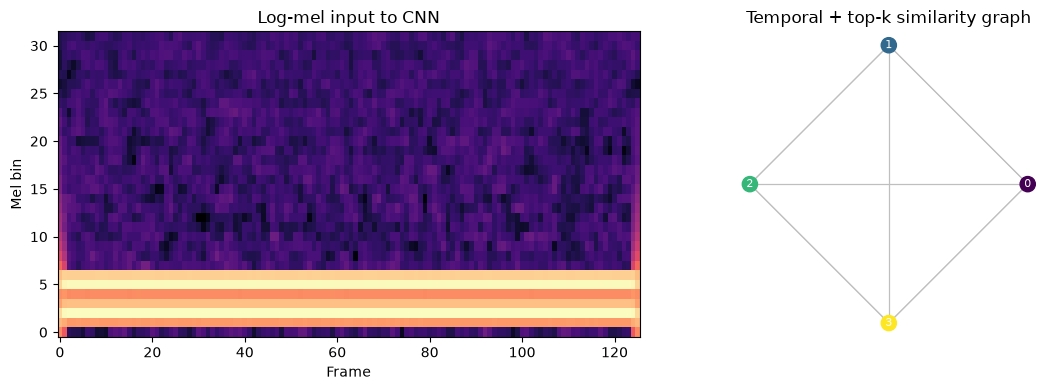

In [15]:
inspection_dataset = ProcessedTask2Dataset(PROCESSED_MANIFEST, 'train', 'temporal_similarity')
sample = inspection_dataset[0]
graph, mel = sample['graph'], sample['mel']
print('Sample:', sample['sample_id'])
print('Nodes x features:', tuple(graph.x.shape))
print('Directed edges:', graph.edge_index.shape[1])
print('Mel tensor:', tuple(mel.shape))
print('Labels:', sample['labels'].tolist())

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(mel.squeeze(0), origin='lower', aspect='auto', cmap='magma')
axes[0].set(title='Log-mel input to CNN', xlabel='Frame', ylabel='Mel bin')
node_count = graph.num_nodes
angles = np.linspace(0, 2 * np.pi, node_count, endpoint=False)
positions = np.c_[np.cos(angles), np.sin(angles)]
for source, target in graph.edge_index.t().tolist():
    axes[1].plot(positions[[source, target], 0], positions[[source, target], 1], color='0.75', linewidth=0.8, zorder=1)
axes[1].scatter(positions[:, 0], positions[:, 1], c=np.arange(node_count), cmap='viridis', s=120, zorder=2)
for index, (x_pos, y_pos) in enumerate(positions):
    axes[1].text(x_pos, y_pos, str(index), ha='center', va='center', color='white', fontsize=8, zorder=3)
axes[1].set(title='Temporal + top-k similarity graph', aspect='equal')
axes[1].axis('off')
figure.tight_layout()

## 6. Model shape smoke test

GraphSAGE performs message passing before mean/max graph pooling. The MLP pools the same nodes without edges, controlling for features and classifier capacity. The CNN receives the clip-level mel image and never sees the graph.

In [16]:
from torch.utils.data import DataLoader

loader = DataLoader(inspection_dataset, batch_size=4, shuffle=False, collate_fn=collate_task2)
batch = next(iter(loader))
input_dim = batch['graph'].x.shape[1]
num_labels = len(inspection_dataset.label_names)
for model_name in ['mlp', 'gnn', 'cnn']:
    model = build_task2_model(model_name, input_dim=input_dim, num_labels=num_labels, hidden_dim=32, layers=2)
    with torch.no_grad():
        logits = model(batch['mel']) if model_name == 'cnn' else model(batch['graph'])
    parameters = sum(parameter.numel() for parameter in model.parameters())
    print(f'{model_name:>3}: logits={tuple(logits.shape)}, parameters={parameters:,}')

mlp: logits=(4, 3), parameters=6,467
gnn: logits=(4, 3), parameters=8,771
cnn: logits=(4, 3), parameters=23,715


## 7. Train baselines and graph ablations

Model selection and the probability threshold use validation Macro-F1 only. For a real experiment, compare validation results first, freeze one configuration, and then evaluate its test result once. Synthetic scores below are smoke-test diagnostics only.

In [17]:
RUN_TRAINING = True
EPOCHS = 2 if USE_SYNTHETIC else 30
experiments = [
    ('mlp', 'temporal'),
    ('cnn', 'temporal'),
    ('gnn', 'temporal'),
    ('gnn', 'temporal_similarity'),
    ('gnn', 'random'),
]
summaries = []
if RUN_TRAINING:
    for model_name, graph_variant in experiments:
        run_name = f'{model_name}_{graph_variant}'
        print(f'\n=== {run_name} ===')
        summary = train_task2(Task2TrainConfig(
            manifest=str(PROCESSED_MANIFEST),
            output_dir=str(RESULTS_DIR / run_name),
            model=model_name,
            graph_variant=graph_variant,
            hidden_dim=32 if USE_SYNTHETIC else 128,
            layers=2,
            batch_size=6 if USE_SYNTHETIC else 16,
            epochs=EPOCHS,
            patience=3 if USE_SYNTHETIC else 5,
            use_pos_weight=not USE_SYNTHETIC,
            seed=SEED,
            device='auto',
            evaluate_test=USE_SYNTHETIC,  # keep real test sealed during ablations
        ))
        summaries.append(summary)
else:
    print('Training skipped. Set RUN_TRAINING = True when ready.')


=== mlp_temporal ===
epoch=01 train_loss=0.6968 val_loss=0.6627 val_macro_f1=0.7222 threshold=0.50
epoch=02 train_loss=0.6410 val_loss=0.6155 val_macro_f1=0.8222 threshold=0.50
{
  "config": {
    "manifest": "C:\\Users\\Roman\\OneDrive\\Documents\\Neural_Project\\tmp\\task2_notebook_demo\\processed\\manifest.json",
    "output_dir": "C:\\Users\\Roman\\OneDrive\\Documents\\Neural_Project\\tmp\\task2_notebook_demo\\results\\mlp_temporal",
    "model": "mlp",
    "graph_variant": "temporal",
    "hidden_dim": 32,
    "layers": 2,
    "dropout": 0.2,
    "batch_size": 6,
    "epochs": 2,
    "learning_rate": 0.001,
    "weight_decay": 1e-05,
    "patience": 3,
    "use_pos_weight": false,
    "seed": 42,
    "device": "auto",
    "num_workers": 0,
    "evaluate_test": true
  },
  "model": "mlp",
  "graph_variant": "temporal",
  "parameter_count": 6467,
  "training_seconds": 0.20201539993286133,
  "best_epoch": 2,
  "best_validation_macro_f1": 0.8222222222222223,
  "validation_threshold":

## 8. Comparison table

In [18]:
comparison_rows = []
for summary in summaries:
    test = summary.get('test') or {}
    comparison_rows.append({
        'model': summary['model'],
        'graph_variant': summary['graph_variant'],
        'parameters': summary['parameter_count'],
        'best_validation_macro_f1': summary['best_validation_macro_f1'],
        'validation_threshold': summary['validation_threshold'],
        'test_macro_f1': test.get('macro_f1'),
        'test_micro_f1': test.get('micro_f1'),
        'test_mAP': test.get('mean_average_precision'),
    })
comparison = pd.DataFrame(comparison_rows)
if not comparison.empty:
    comparison = comparison.sort_values('best_validation_macro_f1', ascending=False)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    comparison.to_csv(RESULTS_DIR / 'comparison.csv', index=False)
comparison

,model,graph_variant,parameters,best_validation_macro_f1,validation_threshold,test_macro_f1,test_micro_f1,test_mAP
2,gnn,temporal,8771,0.833333,0.50,0.266667,0.571429,0.777778
4,gnn,random,8771,0.833333,0.50,0.266667,0.571429,0.777778
3,gnn,temporal_similarity,8771,0.833333,0.50,0.266667,0.571429,0.777778
0,mlp,temporal,6467,0.822222,0.50,1.000000,1.000000,1.000000
1,cnn,temporal,23715,0.600000,0.05,0.600000,0.615385,1.000000


## 9. Interpretation checklist

Before reporting real Task 2 results:

- Confirm every row points to permitted local audio and the correct label vector.
- Keep split IDs identical for MLP, CNN, and every GNN variant.
- Fit feature normalization and class weights on training data only.
- Select graph variant, hidden size, checkpoint, and threshold using validation data only.
- Keep real-data test evaluation disabled during ablations; evaluate one frozen checkpoint once.
- Report parameter counts and runtime alongside Macro-F1, Micro-F1, and mAP.
- Run at least three seeds for selected models.
- A GNN loss to the CNN or random-edge control is a valid negative result; do not hide it.
- Do not present synthetic scores as MusicCaps/FMA/GTZAN results.